In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [3]:
df = pd.read_csv("/content/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.shape

(768, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [8]:
df.dropna(inplace=True)

In [9]:
df.columns = [
    'Region',
    'Date',
    'Frequency',
    'Unemployment_Rate',
    'Employed',
    'Labour_Participation_Rate',
    'Area'
]

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_3907/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

In [12]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9


In [13]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Year,Month
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,2019.418919,6.390541
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000,1.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000,4.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000,6.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000,9.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000,12.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716,3.235070


In [15]:
df['Unemployment_Rate'].mean()

np.float64(11.787945945945946)

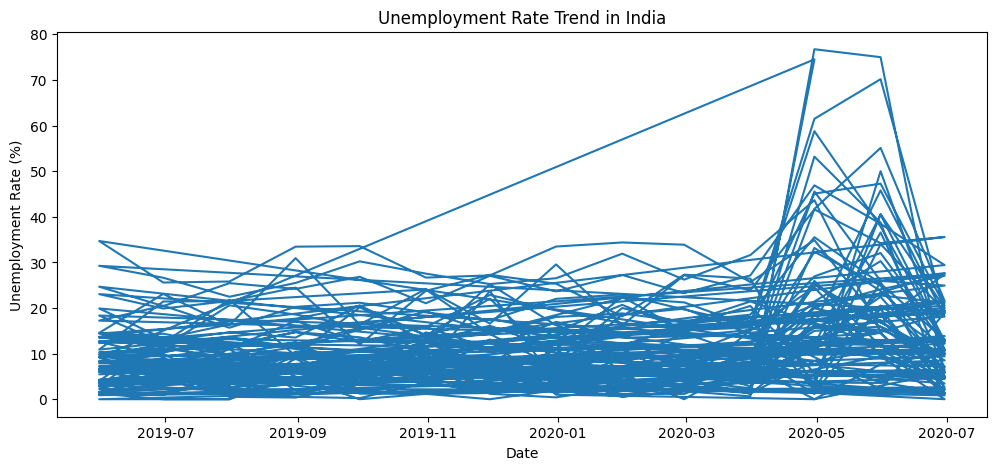

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Unemployment_Rate']
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.title("Unemployment Rate Trend in India")

plt.show()

In [17]:
before_covid = df[df['Date'] < '2020-03-01']

before_covid['Unemployment_Rate'].mean()

np.float64(9.509533582089553)

In [18]:
during_covid = df[
(df['Date'] >= '2020-03-01') &
(df['Date'] <= '2020-12-31')
]


during_covid['Unemployment_Rate'].mean()

np.float64(17.774362745098042)

In [19]:
print("Before COVID:",
before_covid['Unemployment_Rate'].mean())


print("During COVID:",
during_covid['Unemployment_Rate'].mean())

Before COVID: 9.509533582089553
During COVID: 17.774362745098042


In [20]:
state_analysis = (
df.groupby('Region')
['Unemployment_Rate']
.mean()
.sort_values(
ascending=False
)
)


state_analysis.head(10)

,Unemployment_Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


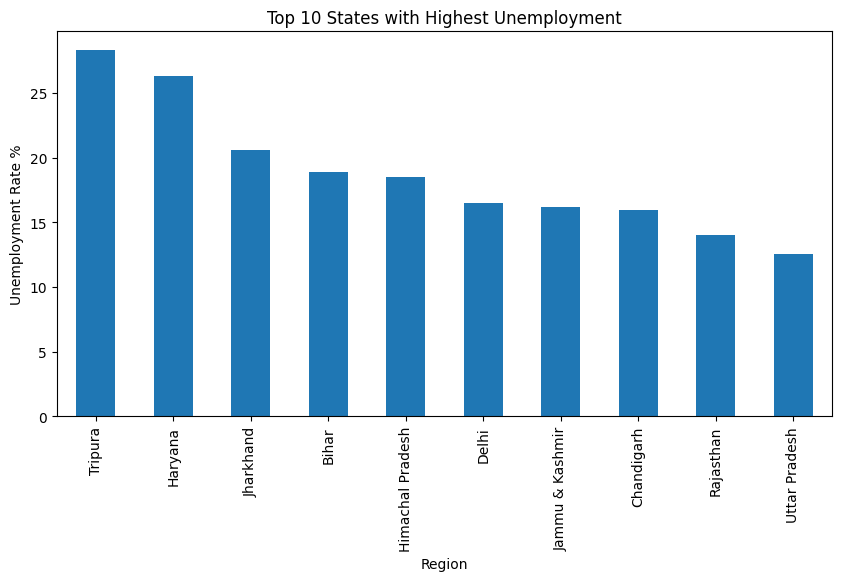

In [21]:
plt.figure(figsize=(10,5))

state_analysis.head(10).plot(kind='bar')

plt.title(
"Top 10 States with Highest Unemployment"
)

plt.ylabel("Unemployment Rate %")

plt.show()

In [22]:
area_analysis = df.groupby('Area')[
'Unemployment_Rate'
].mean()


area_analysis

,Unemployment_Rate
Area,
Rural,10.324791
Urban,13.166614


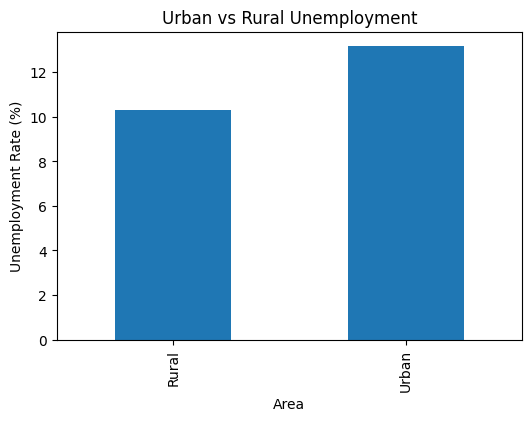

In [23]:
area_analysis.plot(
kind='bar',
figsize=(6,4)
)

plt.title(
"Urban vs Rural Unemployment"
)

plt.ylabel(
"Unemployment Rate (%)"
)

plt.show()

In [24]:
df.corr(numeric_only=True)

,Unemployment_Rate,Employed,Labour_Participation_Rate,Year,Month
Unemployment_Rate,1.000000,-0.222876,0.002558,0.262602,-0.122938
Employed,-0.222876,1.000000,0.011300,-0.031841,0.011285
Labour_Participation_Rate,0.002558,0.011300,1.000000,-0.182460,0.087257
Year,0.262602,-0.031841,-0.182460,1.000000,-0.768484
Month,-0.122938,0.011285,0.087257,-0.768484,1.000000


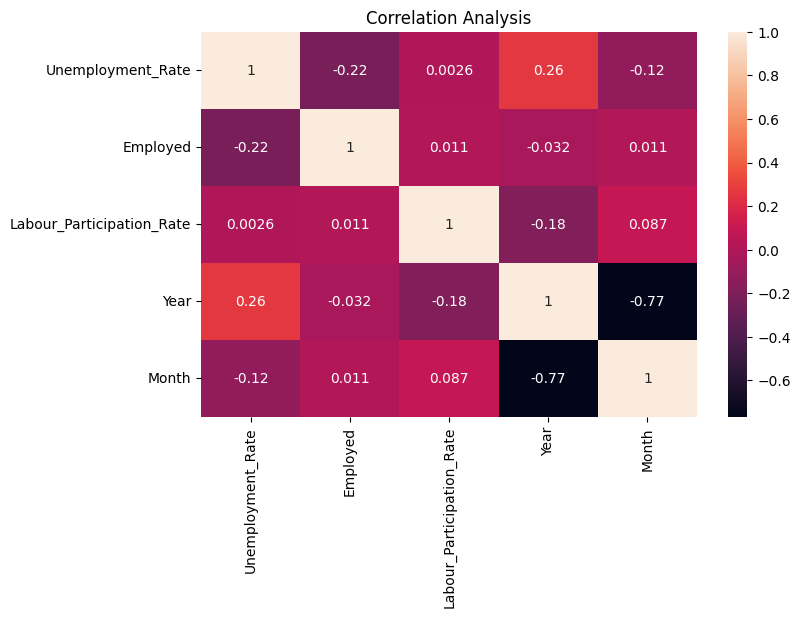

In [25]:
plt.figure(figsize=(8,5))

sns.heatmap(
df.corr(numeric_only=True),
annot=True
)

plt.title(
"Correlation Analysis"
)

plt.show()

In [26]:
from sklearn.model_selection import train_test_split


X=df[
[
'Employed',
'Labour_Participation_Rate',
'Year',
'Month'
]
]


y=df['Unemployment_Rate']


X_train,X_test,y_train,y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression


model=LinearRegression()


model.fit(
X_train,
y_train
)

LinearRegression()

In [28]:
pred=model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error,r2_score


print(
"MAE:",
mean_absolute_error(y_test,pred)
)


print(
"R2 Score:",
r2_score(y_test,pred)
)

MAE: 7.7471363179735935
R2 Score: 0.1455824519607376
